(tutorials:non_orthogonal_grids)=
# Non-orthogonal (skewed) simulation grids

The [previous tutorial](tutorials:orthogonal_cells) explained why the multislice algorithm has always required an orthogonal periodic cell, and how `abtem.orthogonalize_cell` builds an orthogonal supercell out of a non-orthogonal one -- sometimes a rather large one, if the cell angles are unfavourable.

Since *ab*TEM `1.1.0`, this is no longer a hard requirement. If the two in-plane lattice vectors $\mathbf{a}$, $\mathbf{b}$ lie in the $xy$-plane (the only remaining constraint, needed so that slicing perpendicular to the beam stays well defined), simulations can run directly on the native, non-orthogonal ("skewed") grid that matches the cell. There is no separate code path to opt into: `Potential` and the wave function classes auto-detect a non-orthogonal cell and switch grids automatically, while an orthogonal cell keeps using the old, bit-identical path.

## Why a skewed grid still works

A sheared grid is still a Bravais lattice, so the discrete Fourier transform still diagonalizes the free-space propagator exactly as it does on a rectangular grid -- nothing about the multislice derivation in the [walkthrough](walkthrough:multislice) actually assumes orthogonality. The only change is in how a spatial frequency $\vec{g}$ is turned into a scattering angle: instead of the familiar $|\vec{g}|^2 = g_x^2 + g_y^2$, the squared length is measured with the reciprocal metric tensor $M = (A A^T)^{-1}$ built from the real-space cell matrix $A$ (whose rows are $\mathbf{a}$ and $\mathbf{b}$),

```{math}
:label: eq:non_orthogonal_grids:metric
|\vec{g}|^2_M = \vec{g}^{\,T} M \, \vec{g} \quad .
```

For an orthogonal cell $M$ is diagonal and Eq. {eq}`eq:non_orthogonal_grids:metric` reduces to the ordinary Euclidean norm, which is why every orthogonal-cell simulation is unaffected: the metric-aware code paths for the propagator, the projected-potential integrator, the anti-aliasing aperture and the transfer functions all collapse back to the code you already know.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ase.build import graphene

import abtem
from abtem.atoms import orthogonalize_cell

abtem.config.set({"diagnostics.progress_bar": False});

## A hexagonal cell, simulated directly

We reuse the same minimal graphene unit cell as the [orthogonal supercells tutorial](tutorials:orthogonal_cells): a single hexagonal cell with two carbon atoms and 2 Å of vacuum above and below the sheet.

cell lengths (Å): [2.46 2.46 4.  ]
cell angles (°):  [ 90.  90. 120.]


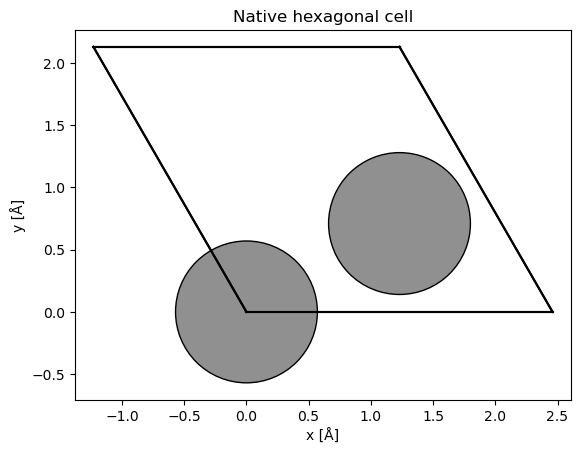

In [2]:
graphene_cell = graphene(vacuum=2)

print("cell lengths (Å):", graphene_cell.cell.lengths())
print("cell angles (°): ", graphene_cell.cell.angles())

abtem.show_atoms(graphene_cell, title="Native hexagonal cell");

The $\gamma$ angle between $\mathbf{a}$ and $\mathbf{b}$ is $120°$, not $90°$: exactly the situation that used to force us to orthogonalize before running multislice. Now we can simply hand this `Atoms` object straight to `Potential`.

In [3]:
skew_potential = abtem.Potential(graphene_cell, sampling=0.05, slice_thickness=4.0)

print("orthogonal grid?", skew_potential.grid.is_orthogonal)
print("gpts:", skew_potential.gpts)
print("potential carries the skew cell:", skew_potential.cell is not None)

orthogonal grid? False
gpts: (50, 50)
potential carries the skew cell: True


No flag was needed: a non-orthogonal cell is detected automatically and `grid.is_orthogonal` reports `False`. Plotting the projected potential shows its true shape -- a parallelogram, not a rectangle -- because the display machinery (`ImageArtist`) also detects the skew cell and renders it with `pcolormesh` instead of the usual `imshow`.

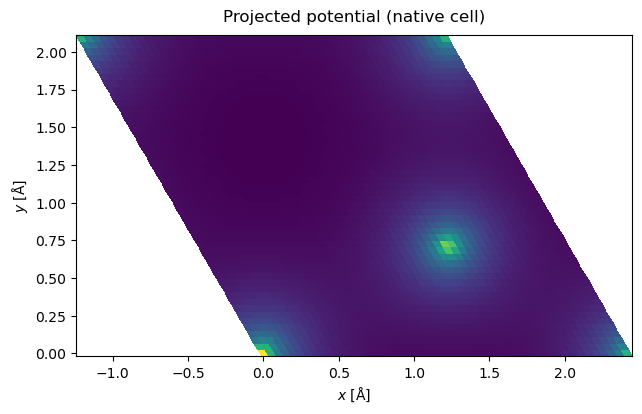

In [4]:
skew_potential.build(lazy=False).compute().show(title="Projected potential (native cell)");

## Checking it against the old way: orthogonalize and compare

To confirm the skewed-grid simulation is doing the right physics, we run the exact same crystal two ways and compare the results:

1. **Direct**, on the native hexagonal cell, as above.
2. **Orthogonalized**, using `orthogonalize_cell` exactly as in the previous tutorial, then simulated on the resulting rectangular supercell with the old code path.

We also tile each potential a few times with the same `CrystalPotential` mechanism used for the $z$-stacking below, this time laterally. This is purely for display: a single unit cell's FFT only puts one or two pixels on each Bragg peak, while a few repetitions give the reciprocal grid enough resolution to resolve them properly. We use $4\times4$ repetitions of the native cell and $4\times2$ repetitions of the orthogonalized cell -- which already contains two primitive cells per repetition -- so that the two potentials cover very nearly the same physical area.

For a fair comparison we also match the real-space pixel size (`sampling`) between the two potentials, and -- purely to exercise the propagator over more than one slice -- stack a handful of copies of the layer along $z$ with `CrystalPotential`. This is not a physically realistic graphite (the layers are not offset or bonded), it is a cheap way to send the wave function through several multislice steps so that any accumulated discrepancy between the two grids would show up.

In [5]:
orthogonal_cell = orthogonalize_cell(graphene_cell)

print("orthogonal cell lengths (Å):", orthogonal_cell.cell.lengths())
print("orthogonal cell angles (°): ", orthogonal_cell.cell.angles())

orthogonal cell lengths (Å): [2.46       4.26084499 4.        ]
orthogonal cell angles (°):  [90. 90. 90.]


In [6]:
n_layers = 10  # a handful of unit cells stacked along z, ~40 Å total

skew_stack = abtem.CrystalPotential(
    abtem.Potential(graphene_cell, sampling=0.05, slice_thickness=4.0),
    (4, 4, n_layers),
)
orthogonal_stack = abtem.CrystalPotential(
    abtem.Potential(orthogonal_cell, sampling=0.05, slice_thickness=4.0),
    (4, 2, n_layers),
)

print("skew potential gpts:      ", skew_stack.gpts, " extent (Å):", skew_stack.extent)
print("orthogonal potential gpts:", orthogonal_stack.gpts, " extent (Å):", orthogonal_stack.extent)

skew potential gpts:       (200, 200)  extent (Å): (9.84, 9.84)
orthogonal potential gpts: (200, 172)  extent (Å): (9.84, 8.521689973238876)


In [7]:
wave = abtem.PlaneWave(energy=100e3)
skew_exit = wave.multislice(skew_stack).compute()
orthogonal_exit = wave.multislice(orthogonal_stack).compute()

### Side by side: potentials and diffraction patterns

Plotting the two tiled potentials and their diffraction patterns together makes both comparisons at once: the real-space parallelogram versus the rectangle in the top row, and -- since `show()` detects the skew cell and switches to `pcolormesh` -- the true (non-rectangular) shape of the corresponding reciprocal-space pattern in the bottom row, rather than the usual `imshow` sheared onto a rectangular pixel grid.

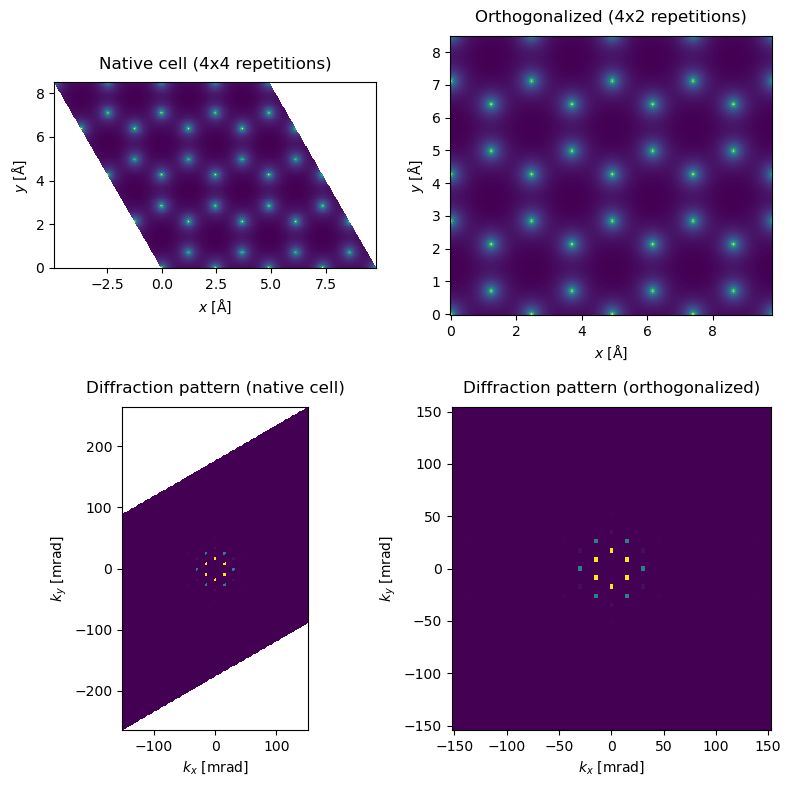

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

skew_stack.build(lazy=False).compute().show(ax=axes[0, 0], title="Native cell (4x4 repetitions)")
orthogonal_stack.build(lazy=False).compute().show(ax=axes[0, 1], title="Orthogonalized (4x2 repetitions)")

skew_exit.diffraction_patterns(max_angle=150).block_direct().show(
    ax=axes[1, 0], units="mrad", title="Diffraction pattern (native cell)"
)
orthogonal_exit.diffraction_patterns(max_angle=150).block_direct().show(
    ax=axes[1, 1], units="mrad", title="Diffraction pattern (orthogonalized)"
)

fig.tight_layout()

The two simulations ran on differently shaped grids (a small parallelogram versus a roughly twice-as-wide rectangle, since the orthogonal cell contains two primitive cells), so we cannot just subtract the exit-wave arrays pixel by pixel. Instead we compare something grid-independent: the intensity of the Bragg reflections of the underlying hexagonal lattice, indexed with `index_diffraction_spots` using the *primitive* graphene cell as the indexing basis for both simulations -- exactly as the [multislice walkthrough](walkthrough:multislice) indexes a repeated gold supercell using its primitive conventional cell. Every reflection of the primitive lattice is also present in the orthogonalized supercell's pattern, so the same set of Miller indices can be looked up in both.

In [9]:
skew_spots = (
    skew_exit.diffraction_patterns(max_angle=150)
    .index_diffraction_spots(cell=graphene_cell.cell)
    .remove_low_intensity(1e-4)
    .to_dataframe()
)
orthogonal_spots = (
    orthogonal_exit.diffraction_patterns(max_angle=150)
    .index_diffraction_spots(cell=graphene_cell.cell)
    .remove_low_intensity(1e-4)
    .to_dataframe()
)

common_hkl = [hkl for hkl in skew_spots.columns if hkl in orthogonal_spots.columns]
skew_values = skew_spots[common_hkl].iloc[0]
orthogonal_values = orthogonal_spots[common_hkl].iloc[0]

relative_difference = (skew_values - orthogonal_values).abs() / orthogonal_values

print(f"compared {len(common_hkl)} shared reflections")
print(f"mean relative difference: {relative_difference.mean():.2%}")
print(f"max relative difference:  {relative_difference.max():.2%}")

compared 25 shared reflections
mean relative difference: 0.67%
max relative difference:  2.53%


The two grids -- one native and skewed, one orthogonalized and twice as large -- agree on every shared Bragg intensity to well under a percent, consistent with the level of agreement reported for the feature (skew primitive cell vs. orthogonalized supercell agree to about $0.3\%$ through tens of Ångströms of dynamical multislice). The small residual comes from the different pixel grids and interpolation during indexing, not from any approximation in the skewed-grid physics.

## Tilted cells and other algorithms

The same auto-detection extends further than the in-plane example above. The third lattice vector $\mathbf{c}$ is also allowed to have in-plane components ($c_x$, $c_y \neq 0$), i.e. a fully triclinic cell -- since the beam travels along Cartesian $+z$ regardless, a tilted $\mathbf{c}$ is handled simply by placing the atoms at their true 3D positions and running ordinary multislice on them, which is exact at any tilt angle (no shear, no propagator phase ramp, no small-angle approximation). And it is not limited to the plane-wave Fourier multislice used here: real-space (finite-difference) multislice, PRISM, and the Bloch-wave dynamical diffraction engine all support non-orthogonal and triclinic cells through the same metric-aware machinery, including `Probe`/STEM simulations and `GridScan`, which tiles the parallelogram cell correctly rather than a rectangle.

```{note} Current limitation
The order-2 correction to the Fourier propagator (available for orthogonal cells via `algorithm=FourierMultislice(order=2)`) is not yet implemented for skewed grids; orthogonal-cell behaviour is unaffected.
```

## What this replaces (and what it doesn't)

```{tip}
Running multislice directly on a native cell means you are no longer *forced* into orthogonalizing just to simulate a small unit cell. If your structure needs frozen-phonon averaging over a large, repeated supercell anyway -- or you specifically need an orthogonal cell for some other tool downstream -- `orthogonalize_cell` (covered in the [previous tutorial](tutorials:orthogonal_cells)) is still the right tool. This feature is about removing an artificial requirement, not about replacing supercells wherever they are still useful.
```